In [1]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical, Sequence
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, Embedding, LSTM, concatenate, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import warnings

In [3]:
# Suppress warnings
warnings.filterwarnings('ignore')

# Paths
image_path = ".\Images"
caption_path = ".\captions.txt"

# Load dataset
data = pd.read_csv(caption_path)

# Image preprocessing function
def readImage(path, img_size=224):
    img = load_img(path, color_mode='rgb', target_size=(img_size, img_size))
    img = img_to_array(img) / 255.0
    return img

# Display sample images with captions
def display_images(temp_df, num_images=5):
    temp_df = temp_df.reset_index(drop=True)
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        image = readImage(os.path.join(image_path, temp_df.image[i]))
        plt.imshow(image)
        plt.title(temp_df.caption[i][:50], fontsize=10)
        plt.axis('off')
    plt.show()

In [4]:
# Text preprocessing
def text_preprocessing(data):
    data['caption'] = data['caption'].apply(lambda x: x.lower().replace('[^a-z]', ' ').strip())
    data['caption'] = data['caption'].apply(lambda x: ' '.join([word for word in x.split() if len(word) > 1]))
    data['caption'] = 'startseq ' + data['caption'] + ' endseq'
    return data

# Preprocess captions
data = text_preprocessing(data)
captions = data['caption'].tolist()

In [5]:
# Tokenize captions
tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in captions)

# Split dataset
images = data['image'].unique().tolist()
nimages = len(images)
split_index = round(0.85 * nimages)
train_images = images[:split_index]
val_images = images[split_index:]

In [6]:
train = data[data['image'].isin(train_images)].reset_index(drop=True)
test = data[data['image'].isin(val_images)].reset_index(drop=True)

# Extract image features using MobileNetV2
model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
fe = Model(inputs=model.input, outputs=model.output)

img_size = 224
features = {}
for image in tqdm(data['image'].unique().tolist(), desc="Extracting features"):
    img = load_img(os.path.join(image_path, image), target_size=(img_size, img_size))
    img = img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)
    feature = fe.predict(img, verbose=0)
    features[image] = feature

9420800/9406464 [==============================] - 0s 0us/step


Extracting features: 100%|██████████| 8091/8091 [06:55<00:00, 19.48it/s]


In [7]:
# Custom data generator
class CustomDataGenerator(Sequence):
    def __init__(self, df, X_col, y_col, batch_size, directory, tokenizer, vocab_size, max_length, features, shuffle=True):
        self.df = df.copy()
        self.X_col = X_col
        self.y_col = y_col
        self.directory = directory
        self.batch_size = batch_size
        self.tokenizer = tokenizer
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.features = features
        self.shuffle = shuffle
        self.n = len(self.df)
        
    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)
    
    def __len__(self):
        return self.n // self.batch_size
    
    def __getitem__(self, index):
        batch = self.df.iloc[index * self.batch_size:(index + 1) * self.batch_size]
        X1, X2, y = self.__get_data(batch)
        return (X1, X2), y
    
    def __get_data(self, batch):
        X1, X2, y = [], [], []
        images = batch[self.X_col].tolist()
        for image in images:
            feature = self.features[image][0]
            captions = batch.loc[batch[self.X_col] == image, self.y_col].tolist()
            for caption in captions:
                seq = self.tokenizer.texts_to_sequences([caption])[0]
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=self.max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=self.vocab_size)[0]
                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)
        return np.array(X1), np.array(X2), np.array(y)

# Create data generators
train_generator = CustomDataGenerator(df=train, X_col='image', y_col='caption', batch_size=32, directory=image_path,
                                     tokenizer=tokenizer, vocab_size=vocab_size, max_length=max_length, features=features)
validation_generator = CustomDataGenerator(df=test, X_col='image', y_col='caption', batch_size=32, directory=image_path,
                                          tokenizer=tokenizer, vocab_size=vocab_size, max_length=max_length, features=features)

In [8]:
# Define lightweight model
input1 = Input(shape=(1280,))  # MobileNetV2 output shape
input2 = Input(shape=(max_length,))
img_features = Dense(128, activation='relu')(input1)
sentence_features = Embedding(vocab_size, 128, mask_zero=False)(input2)
sentence_features = LSTM(128)(sentence_features)
merged = concatenate([img_features, sentence_features])
x = Dropout(0.3)(merged)
x = Dense(64, activation='relu')(x)
output = Dense(vocab_size, activation='softmax')(x)

In [11]:
caption_model = Model(inputs=[input1, input2], outputs=output)
caption_model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001))

# Callbacks
checkpoint = ModelCheckpoint('model.keras', monitor='val_loss', save_best_only=True, verbose=1)
earlystopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)

# Train model
history = caption_model.fit(train_generator, epochs=10, validation_data=validation_generator,
                            callbacks=[checkpoint, earlystopping])

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.savefig('loss_plot.png')
plt.close()

# Save tokenizer and feature extractor
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
fe.save('feature_extractor.keras')

Epoch 1/10
1074/1074 [==============================] - ETA: 0s - loss: 3.3306   
Epoch 1: val_loss improved from inf to 3.73995, saving model to model.keras
1074/1074 [==============================] - 156s 144ms/step - loss: 3.3306 - val_loss: 3.7399
Epoch 2/10
1074/1074 [==============================] - ETA: 0s - loss: 3.2067  
Epoch 2: val_loss did not improve from 3.73995
1074/1074 [==============================] - 107s 99ms/step - loss: 3.2067 - val_loss: 3.7674
Epoch 3/10
1074/1074 [==============================] - ETA: 0s - loss: 3.1288  
Epoch 3: val_loss did not improve from 3.73995
1074/1074 [==============================] - 144s 134ms/step - loss: 3.1288 - val_loss: 3.7787
Epoch 4/10
1074/1074 [==============================] - ETA: 0s - loss: 3.0648  
Epoch 4: val_loss did not improve from 3.73995
Restoring model weights from the end of the best epoch: 1.
1074/1074 [==============================] - 113s 105ms/step - loss: 3.0648 - val_loss: 3.8006
Epoch 4: early stopp

In [12]:
# Function to generate and display captions
def generate_and_display_caption(image_path, model_path='model.keras', tokenizer_path='tokenizer.pkl',
                                feature_extractor_path='feature_extractor.keras', max_length=34, img_size=224):
    # Load models and tokenizer
    caption_model = load_model(model_path)
    feature_extractor = load_model(feature_extractor_path)
    with open(tokenizer_path, 'rb') as f:
        tokenizer = pickle.load(f)

    # Preprocess image
    img = load_img(image_path, target_size=(img_size, img_size))
    img = img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)
    image_features = feature_extractor.predict(img, verbose=0)

    # Generate caption
    in_text = 'startseq'
    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = caption_model.predict([image_features, sequence], verbose=0)
        yhat_index = np.argmax(yhat)
        word = tokenizer.index_word.get(yhat_index)
        if word is None or word == 'endseq':
            break
        in_text += ' ' + word
    caption = in_text.replace('startseq', '').strip()

    # Display image and caption
    plt.figure(figsize=(6, 6))
    plt.imshow(load_img(image_path, target_size=(img_size, img_size)))
    plt.title(caption, fontsize=12)
    plt.axis('off')
    plt.savefig('captioned_image.png')
    plt.close()

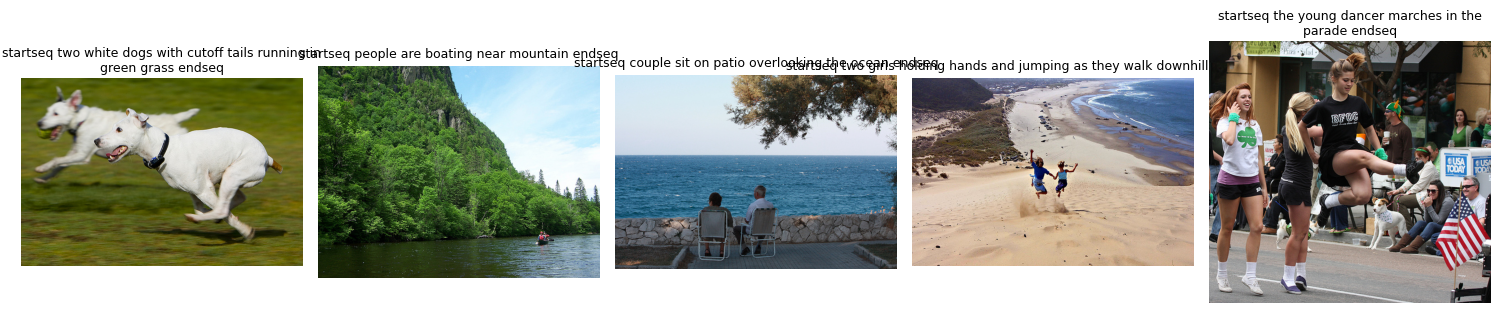

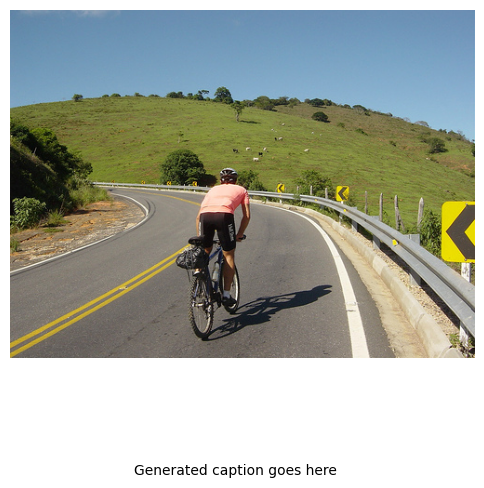

In [20]:
import matplotlib.pyplot as plt
import os

from tensorflow.keras.models import load_model

def display_images(df):
    fig, axes = plt.subplots(1, len(df), figsize=(15, 5))
    if len(df) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, df.iterrows()):
        img_path = os.path.join("./Images", row['image'])
        img = plt.imread(img_path)
        ax.imshow(img)
        ax.set_title(row['caption'], wrap=True, fontsize=9)  # wrapped caption
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def generate_and_display_caption(image_path):
    caption = "Generated caption goes here"  # placeholder for your function
    img = plt.imread(image_path)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")

    # Put caption *below* the image, not overlapping
    plt.figtext(0.5, 0.01, caption, wrap=True, ha="center", fontsize=10)

    plt.show()


# Example usage
if __name__ == "__main__":
    sample_image = './Images/110595925_f3395c8bd6.jpg'
    if os.path.exists(sample_image):
        display_images(data.sample(5))  # captions above/below each subplot
        generate_and_display_caption(sample_image)  # caption below single image
    else:
        print("Sample image not found. Please update the image path.")
